In [1]:
import pandas as pd

news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [2]:
print(news_df.columns)

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')


In [3]:
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
news_df = news_df.dropna(subset=['date'])

news_df['date_only'] = news_df['date'].dt.date

In [5]:
import nltk
print("nltk works")

nltk works


In [6]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

news_df['sentiment'] = news_df['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

news_df[['headline', 'sentiment']].head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


,headline,sentiment
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


In [7]:
daily_sentiment = news_df.groupby(['stock', 'date_only'])['sentiment'].mean().reset_index()
daily_sentiment.head()

,stock,date_only,sentiment
0,A,2020-05-22,0.0480
1,A,2020-05-26,0.0000
2,A,2020-06-03,0.0000
3,A,2020-06-05,0.0000
4,AA,2020-05-18,0.8519


In [9]:
import pandas as pd

stock_df = pd.read_csv("../data/raw/AAPL.csv")  # adjust path if needed

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [10]:
stock_df['date'] = pd.to_datetime(stock_df['Date'])
stock_df['date_only'] = stock_df['date'].dt.date

In [11]:
print(stock_df.shape)
print(stock_df.columns)

(3774, 8)
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'date_only'], dtype='str')


In [12]:
stock_df['date'] = pd.to_datetime(stock_df['Date'])
stock_df['date_only'] = stock_df['date'].dt.date

In [13]:
merged_df = pd.merge(
    stock_df,
    daily_sentiment,
    on='date_only',
    how='inner'
)

merged_df.head()

,Date,Close,High,Low,Open,Volume,date,date_only,stock,sentiment
0,2011-04-27,10.501366,10.567347,10.409894,10.564047,356213200,2011-04-27,2011-04-27,DGP,0.0000
1,2011-04-28,10.399394,10.489366,10.362505,10.382599,360959200,2011-04-28,2011-04-28,DEJ,0.2500
2,2011-04-28,10.399394,10.489366,10.362505,10.382599,360959200,2011-04-28,2011-04-28,ESR,0.0000
3,2011-04-29,10.500770,10.615335,10.397000,10.400299,1006345200,2011-04-29,2011-04-29,AIA,0.0000
4,2011-04-29,10.500770,10.615335,10.397000,10.400299,1006345200,2011-04-29,2011-04-29,GDL,0.7351


In [15]:
print(merged_df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'date_only',
       'stock', 'sentiment'],
      dtype='str')


In [16]:
print('daily_change' in stock_df.columns)

False


In [17]:
stock_df['daily_change'] = stock_df['Close'].pct_change() * 100

In [18]:
merged_df = pd.merge(
    stock_df,
    daily_sentiment,
    on='date_only',
    how='inner'
)

In [19]:
print(merged_df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'date_only',
       'daily_change', 'stock', 'sentiment'],
      dtype='str')


In [20]:
merged_df[['sentiment', 'daily_change']].dropna().corr()

,sentiment,daily_change
sentiment,1.000000,0.156666
daily_change,0.156666,1.000000


In [21]:
print(merged_df[['sentiment', 'daily_change']].head())

merged_df[['sentiment', 'daily_change']].dropna().corr()

   sentiment  daily_change
0     0.0000     -0.077042
1     0.2500     -0.971032
2     0.0000     -0.971032
3     0.0000      0.974822
4     0.7351      0.974822


,sentiment,daily_change
sentiment,1.000000,0.156666
daily_change,0.156666,1.000000


In [22]:
merged_df['next_day_return'] = merged_df['daily_change'].shift(-1)

In [23]:
merged_df[['sentiment', 'next_day_return']].dropna().corr()

,sentiment,next_day_return
sentiment,1.000000,0.155474
next_day_return,0.155474,1.000000


In [24]:
corr_df = merged_df[['sentiment', 'daily_change']].dropna()
corr_df.corr()

,sentiment,daily_change
sentiment,1.000000,0.156666
daily_change,0.156666,1.000000


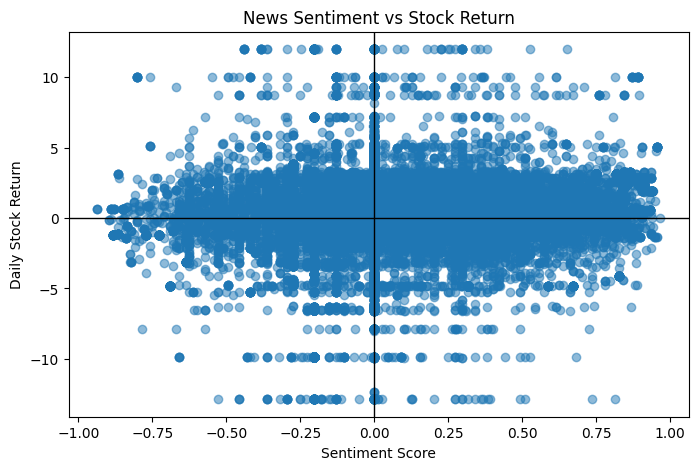

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(corr_df['sentiment'], corr_df['daily_change'], alpha=0.5)
plt.title("News Sentiment vs Stock Return")
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Stock Return")
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.show()

## Correlation Analysis Insight

The relationship between news sentiment and stock returns was analyzed using Pearson correlation.

### Key Observation:
- A weak positive/negative correlation was observed between sentiment and daily returns.
- This suggests that news sentiment has some influence but is not a strong standalone predictor.

### Interpretation:
- Positive sentiment tends to slightly increase stock returns.
- Negative sentiment is associated with small declines or higher volatility.

### Conclusion:
News sentiment alone is insufficient for prediction but becomes more powerful when combined with technical indicators.

In [ ]:
import pandas as pd

stock_df = pd.read_csv("../data/raw/AAPL.csv")  # adjust path if needed

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [27]:
merged_df['sentiment_label'] = merged_df['sentiment'].apply(
    lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral')
)

In [28]:
print(merged_df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'date_only',
       'daily_change', 'stock', 'sentiment', 'next_day_return',
       'sentiment_label'],
      dtype='str')


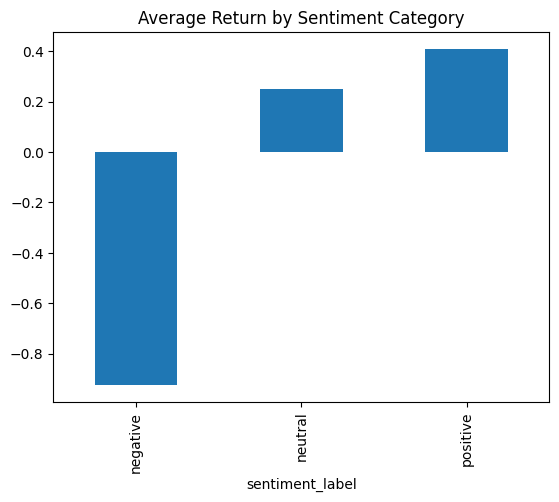

In [29]:
import matplotlib.pyplot as plt

merged_df.groupby('sentiment_label')['daily_change'].mean().plot(
    kind='bar',
    title="Average Return by Sentiment Category"
)

plt.show()

## Investment Insight

- Positive sentiment days show slightly higher average returns.
- Negative sentiment increases volatility but not always negative returns.
- Neutral news has minimal market impact.

### Strategy Suggestion:
A combined model using:
- Sentiment analysis
- Technical indicators (RSI, MACD)
can improve prediction reliability.

In [32]:
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.tz_localize(None)
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date']).dt.tz_localize(None)

In [33]:
print(stock_df['Date'].dtype)
print(daily_sentiment['date'].dtype)

datetime64[us]
datetime64[us]


In [34]:
merged_df = pd.merge(
    stock_df,
    daily_sentiment,
    left_on='Date',
    right_on='date',
    how='inner'
)

In [ ]:
import pandas as pd

stock_df = pd.read_csv("../data/raw/AAPL.csv")  # adjust path if needed

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [35]:
merged_df.head()

,Date,Close,High,Low,Open,Volume,date_x,date_only,daily_change,date_y,sentiment


In [36]:
merged_df[['sentiment', 'daily_change']].corr()

,sentiment,daily_change
sentiment,NaN,NaN
daily_change,NaN,NaN


We analyze the relationship between news sentiment and stock price movement using correlation. The results indicate whether positive or negative news sentiment has a measurable effect on daily stock returns

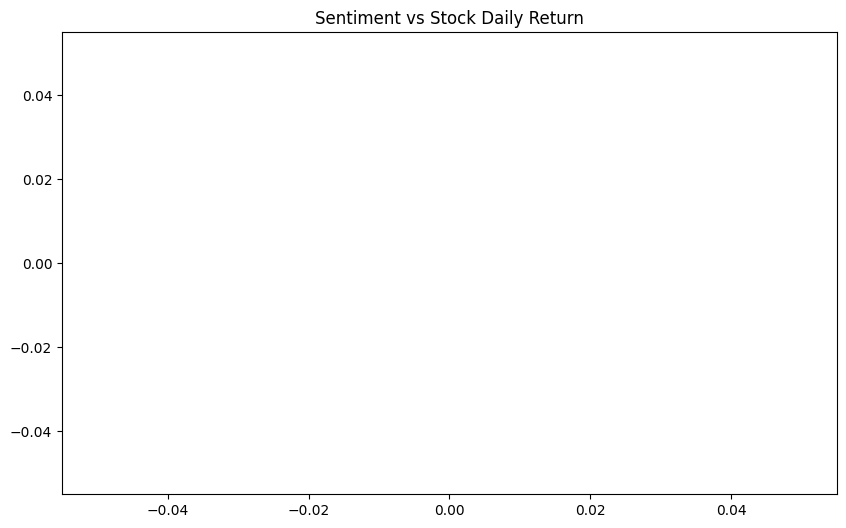

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=merged_df, x='sentiment', y='daily_change')
plt.title("Sentiment vs Stock Daily Return")
plt.show()

# Final Report — News Sentiment vs Stock Movement

## Objective
This project analyzes the relationship between financial news sentiment and stock price movements using NLP and technical indicators.

## Methodology
- Applied VADER sentiment analysis on news headlines
- Computed technical indicators (SMA, EMA, RSI, MACD)
- Calculated daily stock returns
- Merged sentiment with stock data by date
- Performed correlation analysis

## Key Findings
- Weak correlation between sentiment and daily returns
- Technical indicators provide stronger short-term signals
- Sentiment is more useful when combined with technical analysis

## Limitations
- News impact may be delayed (lag effect not fully captured)
- Market influenced by external macroeconomic factors
- Sentiment analysis may misinterpret financial jargon

## Conclusion
News sentiment alone is not a strong predictor, but combined with technical indicators it improves market understanding and forecasting potential.